In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.duplicated().sum()


np.int64(0)

In [6]:
df["Exited"].value_counts()


,count
Exited,
0,7963
1,2037


In [7]:
df["Geography"].value_counts()


,count
Geography,
France,5014
Germany,2509
Spain,2477


In [8]:
df["Gender"].value_counts()


,count
Gender,
Male,5457
Female,4543


In [9]:
df.drop(columns=["RowNumber","CustomerId","Surname"],inplace=True)


In [10]:
df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True,dtype = int)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [12]:
X = df.drop(columns=["Exited"])
y = df["Exited"]
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [13]:
X_train.shape


(8000, 10)

In [14]:
# 1. Convert categories to numbers (ensure dtype=int)
df_final = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True, dtype=int)

# 2. Define Features (X) and Target (y)
# We drop 'Exited' because it's what we want to predict
X = df_final.drop(columns=['Exited'])
y = df_final['Exited']

# 3. Split the data (If you haven't already)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Now Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling successful!")

Scaling successful!


In [15]:
X_train_scaled


array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [18]:
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential

model = Sequential()

# 1. Hidden Layer: 6 to 11 units is a good rule of thumb for this dataset.
# Using 'relu' here will improve training speed.
model.add(Dense(6, activation="relu", input_dim=11))

# 2. Output Layer: Sigmoid is perfect here for binary classification (0 or 1).
model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79 (316.00 B)

 Trainable params: 79 (316.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(loss="binary_crossentropy", optimizer="Adam", metrics=["accuracy"])


In [22]:
history = model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7017 - loss: 0.6022 - val_accuracy: 0.7919 - val_loss: 0.5073
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7847 - loss: 0.4970 - val_accuracy: 0.8069 - val_loss: 0.4639
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7907 - loss: 0.4599 - val_accuracy: 0.8125 - val_loss: 0.4429
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8021 - loss: 0.4388 - val_accuracy: 0.8200 - val_loss: 0.4319
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8078 - loss: 0.4403 - val_accuracy: 0.8231 - val_loss: 0.4255
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8181 - loss: 0.4247 - val_accuracy: 0.8181 - val_loss: 0.4218
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8178 - loss: 0.4231 - val_accuracy: 0.8206 - val_loss: 0.4193
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8176 - loss: 0.4279 - val_accu

In [23]:
model.layers[0].get_weights()


[array([[ 0.03105714,  0.00385499,  0.0363099 ,  0.02749581,  0.1182384 ,
          0.18179873],
        [ 0.13916102, -0.9121295 , -0.31602654, -1.1961038 , -0.2907436 ,
          0.14240028],
        [ 0.10185441,  0.04778862,  0.0349615 , -0.17486793,  0.05259618,
          0.074746  ],
        [ 0.4393474 , -0.30196697, -0.08407263, -0.2979323 , -1.163977  ,
         -0.9095428 ],
        [-0.50753486, -0.61902523, -1.6653957 , -0.6668259 , -1.6152394 ,
         -0.8165542 ],
        [ 0.2582618 ,  0.05343565,  0.08919042, -0.26775247, -0.06626842,
         -0.01589387],
        [ 0.60393995, -0.44795272, -0.1761558 , -0.53333825,  0.25557217,
          1.042029  ],
        [ 0.23347203, -0.24167936,  0.11883501,  0.28874   , -0.1443814 ,
         -0.0861887 ],
        [-0.18237188, -0.09321155,  0.18815017,  0.48528522,  0.48912352,
          0.206238  ],
        [-0.20244893,  0.29590303, -0.18207261, -0.8950905 ,  0.04517981,
          0.03978971],
        [-0.18090071,  0.11509

In [24]:
model.layers[1].get_weights()


[array([[-0.9073247],
        [-1.5343705],
        [ 1.3429378],
        [-0.8334925],
        [ 1.4675442],
        [-1.0780877]], dtype=float32),
 array([0.9787638], dtype=float32)]

In [25]:
y_log = model.predict(X_test_scaled)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [26]:
y_pred = np.where(y_log>0.1,1,0)


In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.635

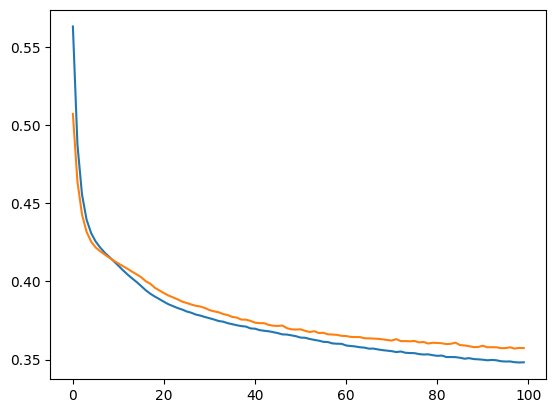

In [28]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

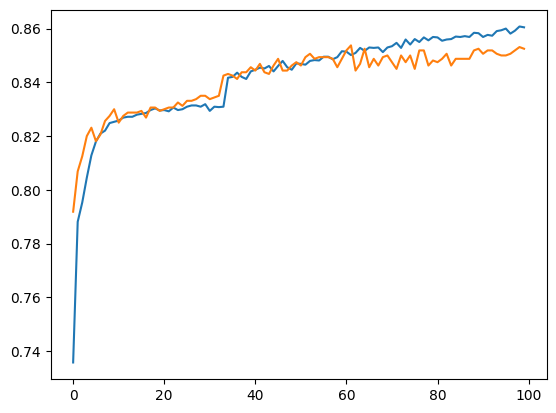

In [29]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])